In [1]:
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print('matplotlib is not installed; plotting helpers will be skipped.')
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from qwen3_ollama import _Scorer, score_application
from src.all_type_parser.all_type_parser import parse_and_save
from src.pool.build_pool import build_chunk_pool
from src.scoring.pipeline import (
    OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE,
    SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE,
    _aggregate_overall,
    _aggregate_section,
    _build_scored_section,
    _generate_json_with_parse_retry,
    _normalize_model_section_output,
    load_rubric,
)

CRITERIA_PATH = PROJECT_ROOT / 'criteria_points.json'
EXPERIMENT_ROOT = PROJECT_ROOT / 'experiments'
SAME_PDF_DIR = PROJECT_ROOT / 'data' / 'reliability'
RESULTS_DIR = EXPERIMENT_ROOT / 'results' / 'reliability_results'
PARSED_CACHE_DIR = RESULTS_DIR / 'parsed_cache'

DEFAULT_SAME_PDF_RUNS_PER_FILE = 3
WHOLE_JSON_BASELINE_MAX_TOKENS = int(os.environ.get('WHOLE_JSON_BASELINE_MAX_TOKENS', '32768'))
EXPERIMENT_OLLAMA_MODEL = 'qwen3.5:27b'  # 改这里即可切换实验模型，例如 'qwen3.5:35b'

for path in [SAME_PDF_DIR, RESULTS_DIR, PARSED_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SECTION_KEYS = [
    'general',
    'proposed_research',
    'training_development',
    'sites_support',
    'wpcc',
    'application_form',
]
SECTION_SCORE_COLUMNS = [f'{section_key}_score_100' for section_key in SECTION_KEYS]
RUN_SCORE_COLUMNS = ['overall_score_100', *SECTION_SCORE_COLUMNS]
RUN_DISPLAY_COLUMNS = ['pdf_name', 'run_idx', *RUN_SCORE_COLUMNS, 'avg_signal_score_0to5']
GROUP_RUN_DISPLAY_COLUMNS = ['group', *RUN_DISPLAY_COLUMNS]

print('Project root:', PROJECT_ROOT)
print('Same PDF dir:', SAME_PDF_DIR)
print('Results dir:', RESULTS_DIR)
print('Default same-pdf runs per file:', DEFAULT_SAME_PDF_RUNS_PER_FILE)
print('Whole-json baseline max tokens:', WHOLE_JSON_BASELINE_MAX_TOKENS)
print('Experiment Ollama model:', EXPERIMENT_OLLAMA_MODEL)


Project root: d:\MSc_AI\SWE_group_project\nlp_grant_coursework
Same PDF dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\reliability
Results dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\experiments\results\reliability_results
Default same-pdf runs per file: 3
Whole-json baseline max tokens: 32768
Experiment Ollama model: qwen3.5:27b


In [2]:
def list_pdfs(folder: Path) -> list[Path]:
    return sorted([path for path in folder.glob('*.pdf') if path.is_file()])


def parse_pdf_cached(pdf_path: Path, *, reparse: bool = False) -> tuple[dict, Path]:
    json_path = PARSED_CACHE_DIR / f'{pdf_path.stem}.json'
    if reparse or not json_path.exists():
        parse_and_save(str(pdf_path), str(json_path))
    parsed = json.loads(json_path.read_text(encoding='utf-8'))
    return parsed, json_path


def make_experiment_scorer(model_name: str | None = None) -> _Scorer:
    return _Scorer(model_name=model_name or EXPERIMENT_OLLAMA_MODEL)


def score_pdf_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    parsed, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    result = score_application(
        parsed,
        CRITERIA_PATH,
        doc_id=f'{pdf_path.stem}_{run_tag}',
        scorer=scorer,
        artifacts_dir=artifact_dir,
    )
    result['source_pdf'] = str(pdf_path)
    result['parsed_json'] = str(parsed_json_path)
    out_path = artifact_dir / f'{pdf_path.stem}_{run_tag}_scored.json'
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    result['result_json'] = str(out_path)
    return result


def compact_prompt_text(text: str, limit: int = 900) -> str:
    compact = ' '.join((text or '').split())
    if len(compact) <= limit:
        return compact
    return compact[:limit] + '...'


def build_baseline_chunk_index(pool_lookup: dict[str, dict[str, str]]) -> list[dict[str, str]]:
    return [
        {
            'chunk_id': chunk_id,
            'parser_section': meta.get('parser_section', ''),
            'source_path': meta.get('source_path', ''),
            'preview': compact_prompt_text(meta.get('text', '')),
        }
        for chunk_id, meta in pool_lookup.items()
    ]


def build_whole_json_baseline_schema(rubric_sections: list[dict], all_chunk_ids: list[str]) -> dict:
    chunk_id_item_schema = {'type': 'string'}
    if all_chunk_ids:
        chunk_id_item_schema['enum'] = all_chunk_ids

    section_properties = {}
    for section in rubric_sections:
        sub_properties = {}
        for sub in section['sub_criteria']:
            signal_properties = {
                signal['sid']: {'type': 'integer', 'enum': [0, 1, 2, 3, 4, 5]}
                for signal in sub['signals']
            }
            sub_properties[sub['sub_id']] = {
                'type': 'object',
                'properties': {
                    'signals': {
                        'type': 'object',
                        'properties': signal_properties,
                        'required': list(signal_properties),
                        'additionalProperties': False,
                    },
                    'used_chunk_ids': {
                        'type': 'array',
                        'items': chunk_id_item_schema,
                        'maxItems': 5,
                    },
                    'pros': {'type': 'string'},
                    'drawbacks': {'type': 'string'},
                },
                'required': ['signals', 'used_chunk_ids', 'pros', 'drawbacks'],
                'additionalProperties': False,
            }
        section_properties[section['section_key']] = {
            'type': 'object',
            'properties': sub_properties,
            'required': list(sub_properties),
            'additionalProperties': False,
        }
    return {
        'type': 'object',
        'properties': section_properties,
        'required': list(section_properties),
        'additionalProperties': False,
    }


def build_whole_json_baseline_messages(
    *,
    parsed_application: dict,
    rubric_sections: list[dict],
    pool_lookup: dict[str, dict[str, str]],
) -> list[dict[str, str]]:
    payload = {
        'task': 'one_shot_whole_parsed_json_baseline_scoring',
        'rules': [
            'Use the full parsed_application_json, criteria, and evidence_chunk_index only.',
            'Make exactly one direct score for every signal in every criterion.',
            'Score each signal as an integer from 0 to 5, where 0 means no evidence and 5 means excellent explicit evidence.',
            'Use used_chunk_ids only from evidence_chunk_index. If there is no relevant support, use an empty list and score weak or absent signals low.',
            'Pros should summarize the strongest support. Drawbacks should summarize missing, weak, inferred, or ambiguous support.',
        ],
        'criteria': rubric_sections,
        'evidence_chunk_index': build_baseline_chunk_index(pool_lookup),
        'parsed_application_json': parsed_application,
    }
    return [
        {
            'role': 'system',
            'content': (
                'You are a strict NIHR grant scoring baseline. You do not use staged retrieval, '
                'belief state, or multi-pass reasoning. Return JSON only and follow the schema exactly.'
            ),
        },
        {'role': 'user', 'content': json.dumps(payload, ensure_ascii=False, indent=2)},
    ]


def score_parsed_json_baseline_once(
    parsed_json_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str = 'whole_json_baseline',
    source_pdf: Path | None = None,
) -> dict:
    parsed_json_path = Path(parsed_json_path)
    parsed = json.loads(parsed_json_path.read_text(encoding='utf-8'))
    doc_type = (parsed.get('doc_type') or '').lower()
    excluded_sections = OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE.get(doc_type, set())
    excluded_sub_ids = SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE.get(doc_type, set())

    rubric_sections = load_rubric(CRITERIA_PATH)
    pool_data = build_chunk_pool(parsed)
    pool_lookup = pool_data['pool_lookup']
    all_chunk_ids = list(pool_lookup)
    chunk_order = {chunk_id: idx for idx, chunk_id in enumerate(all_chunk_ids)}

    messages = build_whole_json_baseline_messages(
        parsed_application=parsed,
        rubric_sections=rubric_sections,
        pool_lookup=pool_lookup,
    )
    schema = build_whole_json_baseline_schema(rubric_sections, all_chunk_ids)
    raw_response, parsed_response, retry_count = _generate_json_with_parse_retry(
        scorer,
        messages,
        schema=schema,
        max_tokens=WHOLE_JSON_BASELINE_MAX_TOKENS,
        max_retries=0,
    )

    sections = []
    for rubric_section in rubric_sections:
        section_key = rubric_section['section_key']
        raw_section = parsed_response.get(section_key, {})
        if not isinstance(raw_section, dict):
            raw_section = {}
        normalized_section = _normalize_model_section_output(raw_section, rubric_section, all_chunk_ids)
        sections.append(_build_scored_section(
            rubric_section,
            normalized_section,
            chunk_order,
            excluded_sub_ids=excluded_sub_ids,
        ))

    features = {
        section['section_key']: _aggregate_section(section, pool_lookup)
        for section in sections
    }
    section_weights = {section['section_key']: section['weight'] for section in sections}
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    raw_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_raw.json'
    sections_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored_sections.json'
    out_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored.json'
    raw_path.write_text(raw_response, encoding='utf-8')
    sections_path.write_text(json.dumps(sections, ensure_ascii=False, indent=2), encoding='utf-8')

    result = {
        'doc_id': f'{parsed_json_path.stem}_{run_tag}',
        'run_info': {
            'ran_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'retrieval_method': 'whole_parsed_json_one_shot_baseline',
            'scorer_model': getattr(scorer, 'model_name', 'unknown'),
        },
        'pool_size': len(pool_lookup),
        'pool_lookup': pool_lookup,
        'section_chunk_ids': pool_data['section_chunk_ids'],
        'features': features,
        'overall': _aggregate_overall(features, section_weights, excluded_sections=excluded_sections),
        'source_pdf': str(source_pdf) if source_pdf else None,
        'parsed_json': str(parsed_json_path),
        'debug': {
            'scoring_contract_version': 'whole_parsed_json_baseline_v1',
            'doc_type': doc_type or None,
            'excluded_sections': sorted(excluded_sections),
            'excluded_sub_ids': sorted(excluded_sub_ids),
            'json_retry_events': [] if retry_count == 0 else [{'stage': 'whole_json_baseline', 'retry_count': retry_count}],
            'artifacts': {
                'raw_response': str(raw_path),
                'scored_sections': str(sections_path),
            },
        },
    }
    result['result_json'] = str(out_path)
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    return result


def score_pdf_whole_json_baseline_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    _, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    return score_parsed_json_baseline_once(
        parsed_json_path,
        scorer=scorer,
        run_tag=run_tag,
        source_pdf=pdf_path,
    )


def run_whole_json_baseline_experiment(
    pdf_paths: list[Path],
    *,
    reparse: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    for idx, pdf_path in enumerate(pdf_paths, start=1):
        run_tag = f'whole_json_baseline_{pdf_path.stem}'
        print(f'[whole_json_baseline {idx}/{len(pdf_paths)}] {pdf_path.name}')
        result = score_pdf_whole_json_baseline_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=1, group='whole_json_baseline')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'whole_json_baseline_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'whole_json_baseline_summary_{timestamp}.csv', index=False)
    return df, summary


def average_signal_score(result: dict) -> float:
    scores = []
    for section in result.get('features', {}).values():
        for criterion in section.get('sub_criteria', section.get('criteria', [])):
            for signal in criterion.get('signals', []):
                scores.append(float(signal.get('score_0to5_raw', signal.get('score', 0)) or 0))
    return round(sum(scores) / len(scores), 4) if scores else 0.0


def flatten_result_row(result: dict, *, pdf_name: str, run_idx: int | None, group: str | None) -> dict:
    overall = result.get('overall', {})
    row = {
        'pdf_name': pdf_name,
        'run_idx': run_idx,
        'group': group,
        'overall_score_100': float(overall.get('final_score_0to100', 0)),
        'overall_score_10': float(overall.get('score_10', 0)),
        'quality_score_100': float(overall.get('quality_score_0to100', 0)),
        'coverage_score_100': float(overall.get('coverage_score_0to100', 0)),
        'avg_signal_score_0to5': average_signal_score(result),
        'total_items': int(overall.get('total_items', 0)),
        'signal_count': int(overall.get('signal_count', 0)),
        'good_items': int(overall.get('good_items', 0)),
        'positive_items': int(overall.get('positive_items', 0)),
        'pool_size': int(result.get('pool_size', 0)),
        'source_pdf': result.get('source_pdf'),
        'parsed_json': result.get('parsed_json'),
        'result_json': result.get('result_json'),
    }
    features = result.get('features', {})
    for section_key in SECTION_KEYS:
        section = features.get(section_key, {})
        section_overall = section.get('overall', {})
        row[f'{section_key}_score_100'] = float(section_overall.get('final_score_0to100', 0))
        row[f'{section_key}_score_10'] = float(section_overall.get('score_10', 0))
        row[f'{section_key}_quality_score_100'] = float(section_overall.get('quality_score_0to100', 0))
        row[f'{section_key}_coverage_score_100'] = float(section_overall.get('coverage_score_0to100', 0))
        row[f'{section_key}_signal_count'] = int(section_overall.get('signal_count', 0))
    return row


def score_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in RUN_SCORE_COLUMNS if col in df.columns]


def score_mean_std_columns(summary: pd.DataFrame) -> list[str]:
    id_cols = [col for col in ['pdf_name', 'group'] if col in summary.columns]
    metric_cols = []
    for metric in RUN_SCORE_COLUMNS:
        for suffix in ['mean', 'std']:
            col = f'{metric}_{suffix}'
            if col in summary.columns:
                metric_cols.append(col)
    if metric_cols:
        return id_cols + metric_cols
    return [col for col in ['metric', 'mean', 'std'] if col in summary.columns]


def format_run_scores(row: dict) -> str:
    parts = [f"overall={float(row.get('overall_score_100', 0)):.1f}"]
    for section_key in SECTION_KEYS:
        col = f'{section_key}_score_100'
        parts.append(f"{section_key}={float(row.get(col, 0)):.1f}")
    return ' | '.join(parts)


def summarize_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    summary = pd.DataFrame({
        'mean': df[columns].mean(),
        'std': df[columns].std(ddof=1),
        'var': df[columns].var(ddof=1),
        'min': df[columns].min(),
        'max': df[columns].max(),
        'median': df[columns].median(),
    }).reset_index().rename(columns={'index': 'metric'})
    return summary


def summarize_distribution(df: pd.DataFrame, *, by: str = 'pdf_name') -> pd.DataFrame:
    columns = score_columns(df)
    summary = df.groupby(by)[columns].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    return summary.reset_index()


def plot_same_pdf(df: pd.DataFrame, pdf_name: str) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df['run_idx'], df['overall_score_100'], marker='o')
    axes[0].set_title(f'Overall score by run: {pdf_name}')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)

    axes[1].boxplot(df['overall_score_100'], vert=True)
    axes[1].set_title('Overall score distribution')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def plot_same_pdf_distribution(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    pdf_names = sorted(df['pdf_name'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(max(14, len(pdf_names) * 2.2), 4.5))
    for pdf_name, pdf_df in df.groupby('pdf_name'):
        axes[0].plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o', label=pdf_name)
    axes[0].set_title('Overall score by run')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    grouped = [df.loc[df['pdf_name'] == pdf_name, 'overall_score_100'].tolist() for pdf_name in pdf_names]
    axes[1].boxplot(grouped, tick_labels=pdf_names)
    axes[1].set_title('Overall score distribution by PDF')
    axes[1].set_ylabel('Score / 100')
    axes[1].tick_params(axis='x', labelrotation=35)
    plt.tight_layout()
    plt.show()


def plot_group_compare(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for group_name, group_df in df.groupby('group'):
        axes[0].hist(group_df['overall_score_100'], bins=min(10, max(3, len(group_df))), alpha=0.5, label=group_name)
    axes[0].set_title('Overall score distribution by group')
    axes[0].set_xlabel('Score / 100')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    grouped = [group_df['overall_score_100'].tolist() for _, group_df in sorted(df.groupby('group'))]
    labels = [group_name for group_name, _ in sorted(df.groupby('group'))]
    axes[1].boxplot(grouped, tick_labels=labels)
    axes[1].set_title('Overall score boxplot')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def optional_stat_tests(group_a_scores: pd.Series, group_b_scores: pd.Series) -> pd.DataFrame:
    rows = []
    try:
        from scipy.stats import ks_2samp, ttest_ind
        t_stat, t_p = ttest_ind(group_a_scores, group_b_scores, equal_var=False)
        ks_stat, ks_p = ks_2samp(group_a_scores, group_b_scores)
        rows.append({'test': 'welch_ttest', 'statistic': float(t_stat), 'p_value': float(t_p)})
        rows.append({'test': 'ks_2samp', 'statistic': float(ks_stat), 'p_value': float(ks_p)})
    except Exception as exc:
        rows.append({'test': 'scipy_unavailable', 'statistic': None, 'p_value': None, 'note': str(exc)})
    return pd.DataFrame(rows)


def run_same_pdf_experiment(
    pdf_path: Path,
    *,
    n_runs: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for run_idx in range(1, n_runs + 1):
        run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
        print(f'[{pdf_path.name}] run {run_idx}/{n_runs}')
        result = score_pdf_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse_each_run,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_numeric(df, score_columns(df))
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_summary_{timestamp}.csv', index=False)
    return df, summary


def run_same_pdf_distribution_experiment(
    pdf_paths: list[Path],
    *,
    runs_per_pdf: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    total_runs = len(pdf_paths) * runs_per_pdf
    completed = 0
    for pdf_path in pdf_paths:
        for run_idx in range(1, runs_per_pdf + 1):
            completed += 1
            run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
            print(f'[{completed}/{total_runs}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
            result = score_pdf_once(
                pdf_path,
                scorer=scorer,
                run_tag=run_tag,
                reparse=reparse_each_run,
            )
            row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
            rows.append(row)
            print(f'  scores | {format_run_scores(row)}')
            if sleep_seconds > 0:
                time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_distribution_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_distribution_summary_{timestamp}.csv', index=False)
    return df, summary


def run_group_compare_experiment(
    *,
    group_a_paths: list[Path],
    group_b_paths: list[Path],
    runs_per_pdf: int = 1,
    reparse_each_run: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for group_name, pdf_paths in [('group_a', group_a_paths), ('group_b', group_b_paths)]:
        for pdf_path in pdf_paths:
            for run_idx in range(1, runs_per_pdf + 1):
                run_tag = f'{group_name}_{pdf_path.stem}_run_{run_idx:02d}'
                print(f'[{group_name}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
                result = score_pdf_once(
                    pdf_path,
                    scorer=scorer,
                    run_tag=run_tag,
                    reparse=reparse_each_run,
                )
                row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group=group_name)
                rows.append(row)
                print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    score_cols = score_columns(df)
    summary = df.groupby('group')[score_cols].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    summary = summary.reset_index()
    tests = optional_stat_tests(
        df.loc[df['group'] == 'group_a', 'overall_score_100'],
        df.loc[df['group'] == 'group_b', 'overall_score_100'],
    )
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'group_compare_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'group_compare_summary_{timestamp}.csv')
    tests.to_csv(RESULTS_DIR / f'group_compare_tests_{timestamp}.csv', index=False)
    return df, summary, tests


[qwen3_ollama] using http://127.0.0.1:11434 model=qwen3.5:27b
[1/30] IC00001_DF_Doctoral.pdf run 1/3
[all_type_parser] ✓ fellowships_parser succeeded
[all_type_parser] saved → d:\MSc_AI\SWE_group_project\nlp_grant_coursework\experiments\results\reliability_results\parsed_cache\IC00001_DF_Doctoral.json
  scores | overall=87.4 | general=90.0 | proposed_research=92.1 | training_development=80.0 | sites_support=95.0 | wpcc=82.2 | application_form=85.0
[2/30] IC00001_DF_Doctoral.pdf run 2/3
  scores | overall=90.2 | general=92.0 | proposed_research=97.5 | training_development=86.7 | sites_support=95.0 | wpcc=90.0 | application_form=80.0
[3/30] IC00001_DF_Doctoral.pdf run 3/3
  scores | overall=84.7 | general=87.0 | proposed_research=94.2 | training_development=86.7 | sites_support=83.8 | wpcc=76.7 | application_form=80.0
[4/30] IC00029_RfPB.pdf run 1/3
[all_type_parser] detected RfPB PDF — using RfPB_parser directly
[all_type_parser] ✓ RfPB_parser succeeded
[all_type_parser] saved → d:\MSc_

,pdf_name,run_idx,overall_score_100,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100,avg_signal_score_0to5
0,IC00001_DF_Doctoral.pdf,1,87.4,90.0,92.1,80.0,95.0,82.2,85.0,4.4554
1,IC00001_DF_Doctoral.pdf,2,90.2,92.0,97.5,86.7,95.0,90.0,80.0,4.5804
2,IC00001_DF_Doctoral.pdf,3,84.7,87.0,94.2,86.7,83.8,76.7,80.0,4.3036
3,IC00029_RfPB.pdf,1,82.9,72.8,100.0,0.0,71.2,87.8,82.8,3.6250
4,IC00029_RfPB.pdf,2,80.0,65.0,97.5,0.0,68.8,88.9,80.0,3.4821
5,IC00029_RfPB.pdf,3,84.3,72.8,95.0,0.0,80.0,88.9,85.0,3.7232
6,IC00087_DCAF_Doctoral.pdf,1,90.8,87.0,92.5,93.3,100.0,86.7,85.0,4.5536
7,IC00087_DCAF_Doctoral.pdf,2,91.4,87.0,91.7,91.7,100.0,93.3,85.0,4.5893
8,IC00087_DCAF_Doctoral.pdf,3,88.6,94.0,96.2,80.0,88.8,87.8,85.0,4.5357
9,IC00091_AF_Postdoctoral.pdf,1,87.8,94.0,87.5,93.3,80.0,86.7,85.0,4.4018


,pdf_name,overall_score_100_mean,overall_score_100_std,general_score_100_mean,general_score_100_std,proposed_research_score_100_mean,proposed_research_score_100_std,training_development_score_100_mean,training_development_score_100_std,sites_support_score_100_mean,sites_support_score_100_std,wpcc_score_100_mean,wpcc_score_100_std,application_form_score_100_mean,application_form_score_100_std
0,IC00001_DF_Doctoral.pdf,87.433333,2.750152,89.666667,2.516611,94.600000,2.722132,84.466667,3.868247,91.266667,6.466323,82.966667,6.683063,81.666667,2.886751
1,IC00029_RfPB.pdf,82.400000,2.193171,70.200000,4.503332,97.500000,2.500000,0.000000,0.000000,73.333333,5.896892,88.533333,0.635085,82.600000,2.505993
2,IC00087_DCAF_Doctoral.pdf,90.266667,1.474223,89.333333,4.041452,93.466667,2.400694,88.333333,7.261083,96.266667,6.466323,89.266667,3.536005,85.000000,0.000000
3,IC00091_AF_Postdoctoral.pdf,87.100000,2.042058,90.333333,3.511885,89.700000,3.143247,91.100000,10.179882,88.766667,7.619930,79.266667,6.539368,83.333333,2.886751
4,IC00157_ACAF_Postdoctoral.pdf,81.533333,2.236813,87.000000,3.000000,84.466667,0.461880,84.466667,3.868247,87.133333,5.773503,55.566667,9.641749,90.533333,9.458506
5,IC00159_RfPB.pdf,77.366667,1.563117,71.266667,6.109283,87.233333,4.792007,0.000000,0.000000,70.833333,3.818813,75.566667,3.868247,81.866667,3.689625
6,IC00458_RfPB.pdf,47.733333,0.404145,11.766667,1.858315,89.400000,0.000000,0.000000,0.000000,10.033333,3.326159,85.166667,3.233162,89.966667,0.981495
7,IC00464_after.pdf,84.066667,2.761038,74.900000,3.651027,92.633333,1.320353,67.233333,7.514209,85.866667,3.579572,95.900000,0.692820,87.766667,3.868247
8,IC00494_after.pdf,58.266667,1.429452,16.433333,0.513160,91.900000,0.000000,7.766667,9.458506,62.500000,0.000000,84.400000,1.100000,86.466667,2.540341
9,IC00527_after.pdf,83.233333,0.404145,84.333333,1.527525,88.933333,2.502665,76.100000,1.905256,75.000000,3.800000,88.166667,2.540341,86.833333,2.502665


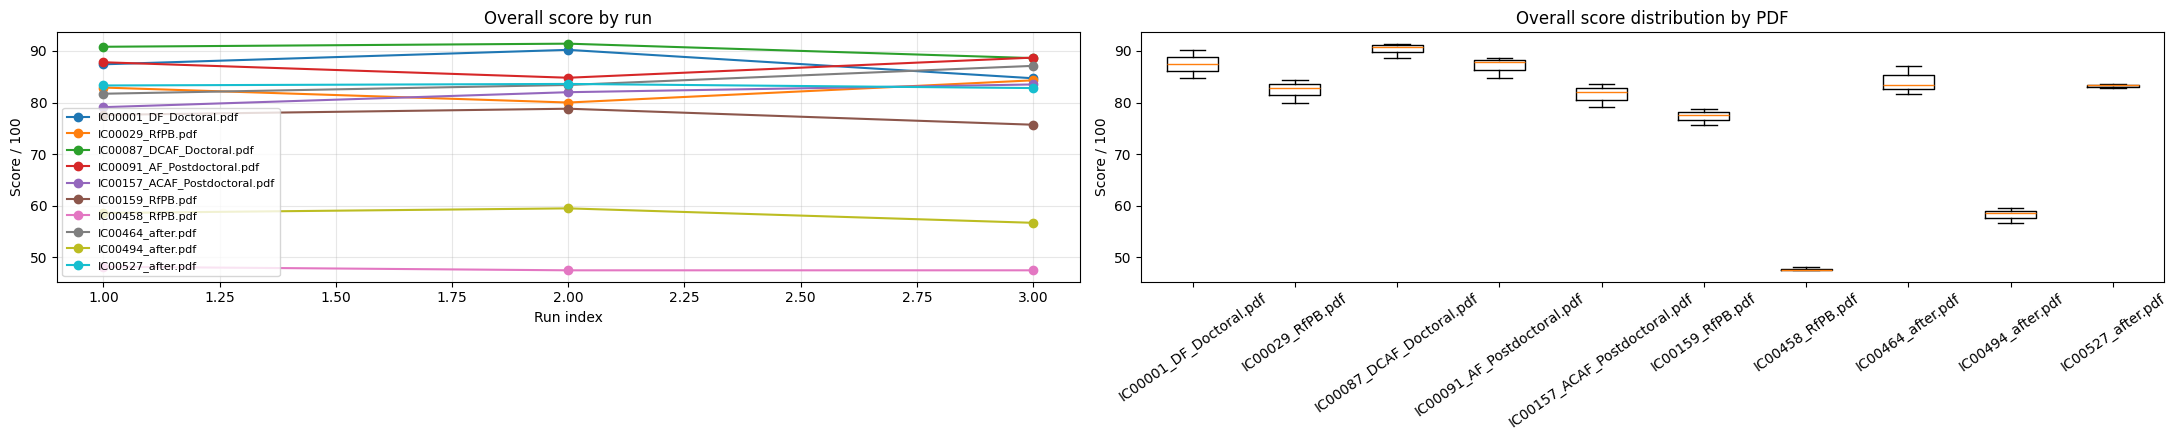

In [3]:
same_pdf_files = list_pdfs(SAME_PDF_DIR)
assert same_pdf_files, f'请在 {SAME_PDF_DIR} 里至少放 1 个 PDF。'

same_pdf_df, same_pdf_summary = run_same_pdf_distribution_experiment(
    same_pdf_files,
    runs_per_pdf=DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run=False,
    sleep_seconds=0.0,
)

display(same_pdf_df[RUN_DISPLAY_COLUMNS])
display(same_pdf_summary[score_mean_std_columns(same_pdf_summary)])
plot_same_pdf_distribution(same_pdf_df)
